# Kidney Disease Dataset
## Mini-EDA y Pipeline de Preprocesamiento
##### Elaborado por: Sofía Quiroz Valencia

En este proyecto se trabajará con el dataset Kidney Disease Dataset, con el propósito de realizar una exploración inicial de los datos (Mini-EDA) y posteriormente construir un pipeline de preprocesamiento utilizando herramientas de scikit-learn.

El dataset utilizado en este proyecto corresponde a información clínica de pacientes relacionada con la enfermedad renal crónica (Chronic Kidney Disease - CKD).

El objetivo principal del dataset es analizar diferentes características clínicas y de laboratorio de los pacientes para determinar si presentan o no enfermedad renal crónica. Para este proyecto se seleccionaron 9 variables, incluyendo 8 variables predictoras y una variable objetivo.

La variable objetivo es classification, que permite clasificar a los pacientes entre aquellos que presentan enfermedad renal crónica (ckd) y aquellos que no la presentan (notckd).

### Variables utilizadas
| Variable           | Descripción                                               | Tipo               |
| ------------------ | --------------------------------------------------------- | ------------------ |
| **age**            | Edad del paciente                                         | Numérica           |
| **bp**             | Presión arterial                                          | Numérica           |
| **bgr**            | Nivel de glucosa aleatoria en sangre                      | Numérica           |
| **hemo**           | Nivel de hemoglobina                                      | Numérica           |
| **rbc**            | Condición de los glóbulos rojos: normal o anormal         | Categórica nominal |
| **htn**            | Presencia de hipertensión: sí o no                        | Categórica nominal |
| **al**             | Nivel de albúmina en la orina                             | Categórica ordinal |
| **su**             | Nivel de azúcar en la orina                               | Categórica ordinal |
| **classification** | Clasificación del paciente: enfermedad renal crónica o no | Variable objetivo  |


#### Importar librerias y cargar base

In [48]:
import pandas as pd
df = pd.read_csv(r"C:\Documentos\OCTAVO SEMESTRE\Ciencia de Datos II\Datasets\kidney_disease.csv")
df.head()


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


#### Definir variables a utilizar 

In [7]:
variables = [
    "age", "bp", "bgr", "hemo",
    "rbc", "htn", "al", "su", "classification"
]

df_eda = df[variables]

df_eda.head()

,age,bp,bgr,hemo,rbc,htn,al,su,classification
0,48.0,80.0,121.0,15.4,NaN,yes,1.0,0.0,ckd
1,7.0,50.0,NaN,11.3,NaN,no,4.0,0.0,ckd
2,62.0,80.0,423.0,9.6,normal,no,2.0,3.0,ckd
3,48.0,70.0,117.0,11.2,normal,yes,4.0,0.0,ckd
4,51.0,80.0,106.0,11.6,normal,no,2.0,0.0,ckd


#### Tipo de cada variable

In [ ]:
df_eda.dtypes

age               float64
bp                float64
bgr               float64
hemo              float64
rbc                object
htn                object
al                float64
su                float64
classification     object
dtype: object

In [9]:
info_variables = pd.DataFrame({
    "Variable": df_eda.columns,
    "Tipo_Python": df_eda.dtypes.astype(str)
})

info_variables

,Variable,Tipo_Python
age,age,float64
bp,bp,float64
bgr,bgr,float64
hemo,hemo,float64
rbc,rbc,object
htn,htn,object
al,al,float64
su,su,float64
classification,classification,object


#### Datos Faltantes

In [11]:
faltantes = pd.DataFrame({
    "Datos_faltantes": df_eda.isna().sum(),
    "Porcentaje": df_eda.isna().mean() * 100
})

faltantes

,Datos_faltantes,Porcentaje
age,9,2.25
bp,12,3.00
bgr,44,11.00
hemo,52,13.00
rbc,152,38.00
htn,2,0.50
al,46,11.50
su,49,12.25
classification,0,0.00


Se identificaron datos faltantes en 8 de las 9 variables seleccionadas. La variable con mayor cantidad de datos faltantes es rbc, con un 38%, seguida de hemo con 13% y su con 12,25%. Por otro lado, classification, que corresponde a la variable objetivo, no presenta datos faltantes.

#### Variables Numéricas

In [12]:
numericas = ["age", "bp", "bgr", "hemo"]

df_eda[numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
age,391.0,51.483376,17.169714,2.0,42.0,55.00,64.5,90.0
bp,388.0,76.469072,13.683637,50.0,70.0,80.00,80.0,180.0
bgr,356.0,148.036517,79.281714,22.0,99.0,121.00,163.0,490.0
hemo,348.0,12.526437,2.912587,3.1,10.3,12.65,15.0,17.8


#### Rangos variables numéricas

In [14]:
rangos = pd.DataFrame({
    "Mínimo": df_eda[numericas].min(),
    "Máximo": df_eda[numericas].max(),
    "Media": df_eda[numericas].mean(),
    "Mediana": df_eda[numericas].median()
})

rangos

,Mínimo,Máximo,Media,Mediana
age,2.0,90.0,51.483376,55.00
bp,50.0,180.0,76.469072,80.00
bgr,22.0,490.0,148.036517,121.00
hemo,3.1,17.8,12.526437,12.65


Las variables numéricas presentan diferentes rangos de valores. age varía entre 2 y 90 años, bp entre 50 y 180, bgr entre 22 y 490 y hemo entre 3,1 y 17,8. Debido a que las variables se encuentran en escalas diferentes, se utilizará StandardScaler para estandarizarlas dentro del pipeline. Además, los valores faltantes serán imputados utilizando la mediana de cada variable.

#### Distribución variables numéricas

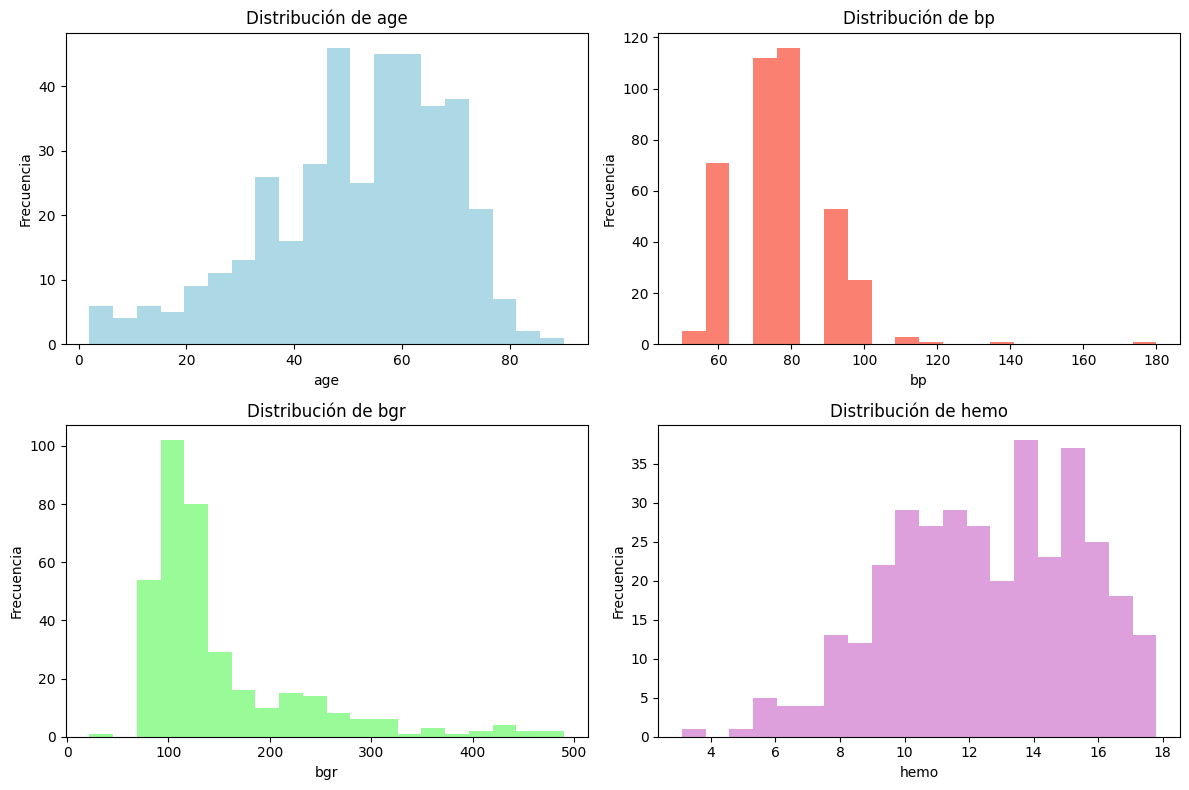

In [56]:
import matplotlib.pyplot as plt

numericas = ["age", "bp", "bgr", "hemo"]
colores = ["lightblue", "salmon", "palegreen", "plum"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes = axes.flatten()

for ax, variable, color in zip(axes, numericas, colores):
    ax.hist(df_eda[variable].dropna(), bins=20, color=color)  
    ax.set_title(f"Distribución de {variable}")
    ax.set_xlabel(variable)  
    ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

#### Variables Categóricas

In [15]:
categoricas = ["rbc", "htn", "al", "su", "classification"]

for variable in categoricas:
    print("\n", variable)
    print(df_eda[variable].value_counts(dropna=False))


 rbc
rbc
normal      201
NaN         152
abnormal     47
Name: count, dtype: int64

 htn
htn
no     251
yes    147
NaN      2
Name: count, dtype: int64

 al
al
0.0    199
NaN     46
1.0     44
3.0     43
2.0     43
4.0     24
5.0      1
Name: count, dtype: int64

 su
su
0.0    290
NaN     49
2.0     18
3.0     14
4.0     13
1.0     13
5.0      3
Name: count, dtype: int64

 classification
classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64


In [16]:
df_eda.dtypes

age               float64
bp                float64
bgr               float64
hemo              float64
rbc                object
htn                object
al                float64
su                float64
classification     object
dtype: object

C:\Users\sofia\AppData\Local\Temp\ipykernel_11128\55594749.py:17: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sofia\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


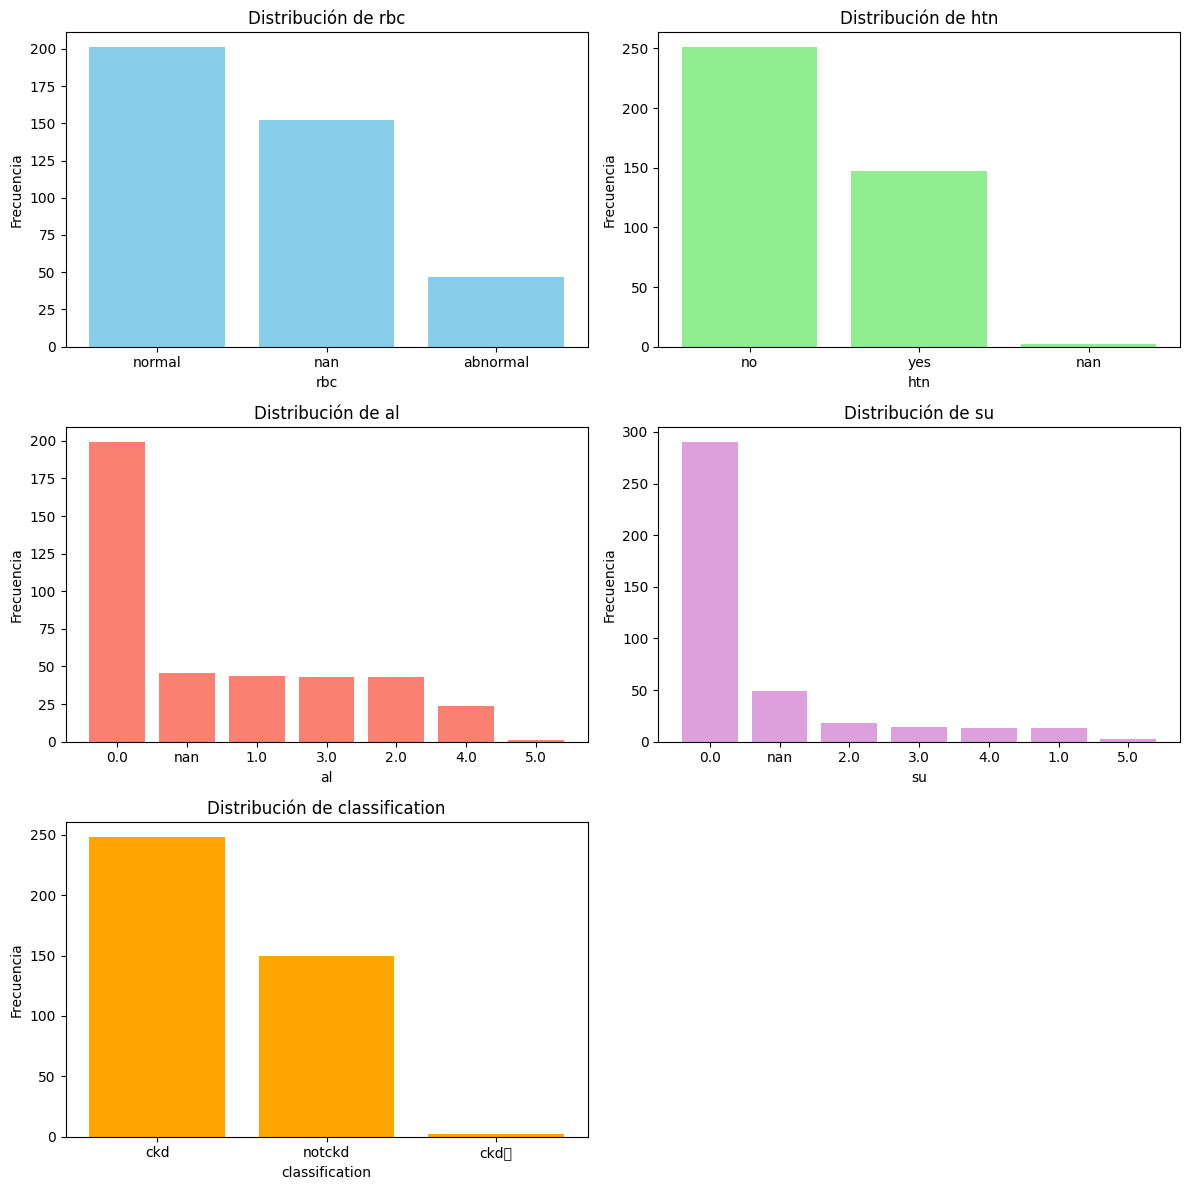

In [57]:
categoricas = ["rbc", "htn", "al", "su", "classification"]
colores = ["skyblue", "lightgreen", "salmon", "plum", "orange"]
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

axes = axes.flatten()

for ax, variable, color in zip(axes, categoricas, colores):
    conteo = df_eda[variable].value_counts(dropna=False)
    ax.bar(conteo.index.astype(str), conteo.values, color=color)
    ax.set_title(f"Distribución de {variable}")
    ax.set_xlabel(variable)
    ax.set_ylabel("Frecuencia")

# Eliminar la gráfica vacía porque son 5 variables y hay 6 espacios
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

##### Variables categóricas: 
Las variables categóricas analizadas permiten identificar características clínicas y la clasificación de los pacientes. La variable rbc indica si los glóbulos rojos presentan una condición normal o anormal, mientras que htn identifica la presencia o ausencia de hipertensión. Las variables al y su representan niveles de albúmina y azúcar en la orina, respectivamente, mediante valores ordinales. Finalmente, classification corresponde a la variable objetivo, clasificando a los pacientes con enfermedad renal crónica (ckd) o sin enfermedad renal crónica (notckd).



| **Variable**       | **Significado**                  | **Categorías**       |
| ------------------ | -------------------------------- | -------------------- |
| **rbc**            | Red Blood Cells / Glóbulos rojos | `normal`, `abnormal` |
| **htn**            | Hypertension / Hipertensión      | `yes`, `no`          |
| **al**             | Albumin / Albúmina en la orina   | Niveles de `0` a `5` |
| **su**             | Sugar / Azúcar en la orina       | Niveles de `0` a `5` |
| **classification** | Clasificación o diagnóstico      | `ckd`, `notckd`      |


#### Distribución datos faltantes por variable

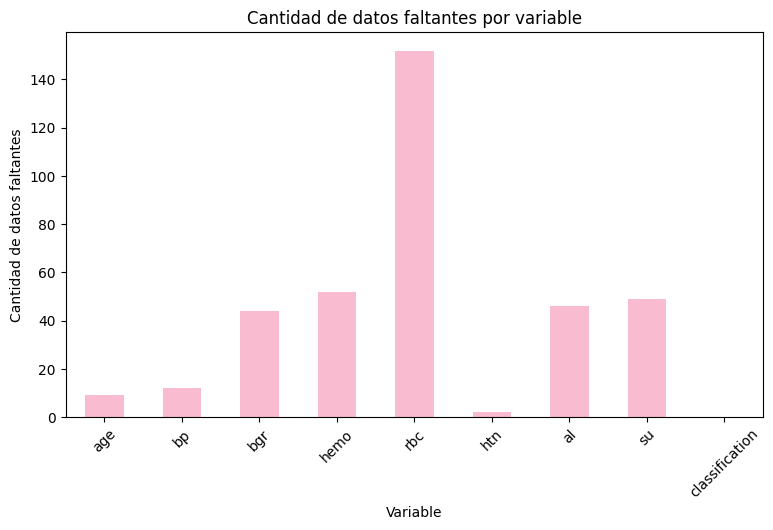

In [78]:
faltantes = df_eda.isna().sum()


plt.figure(figsize=(9, 5))
faltantes.plot(kind="bar", color="#F8BBD0")
plt.title("Cantidad de datos faltantes por variable")
plt.xlabel("Variable")
plt.ylabel("Cantidad de datos faltantes")
plt.xticks(rotation=45)
plt.show()

## PIPELINE

In [61]:
import numpy as np

#### Importar librerias

In [62]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder,
    FunctionTransformer
)
from sklearn.impute import SimpleImputer

#### Seleccionar Variables

In [63]:
variables = [
    "age", "bp", "bgr", "hemo",
    "rbc", "htn", "al", "su", "classification"
]

df_eda = df[variables].copy()

#### Custom Transformer — Limpieza de datos

In [64]:
def limpiar_datos(X):
    X = X.copy()

    # Reemplazar valores ? por NaN
    X = X.replace("?", np.nan)

    # Limpiar espacios en variables de texto
    for columna in X.select_dtypes(include="object").columns:
        X[columna] = X[columna].str.strip().str.lower()

    return X

Posteriormente, la función se convierte en un FunctionTransformer:

In [65]:
custom_transformer = FunctionTransformer(
    limpiar_datos,
    validate=False
)

#### Definición de variables según su tipo

In [66]:
numericas = ["age", "bp", "bgr", "hemo"]

nominales = ["rbc", "htn"]

ordinales = ["al", "su"]

#### Pipeline para variables numéricas

In [67]:
pipeline_numericas = Pipeline([
    ("imputacion", SimpleImputer(strategy="median")),
    ("escalamiento", StandardScaler())
])

#### Pipeline para variables nominales

In [68]:
pipeline_nominales = Pipeline([
    ("imputacion", SimpleImputer(strategy="most_frequent")),
    ("codificacion", OneHotEncoder(handle_unknown="ignore"))
])

#### Pipeline para variables ordinales

In [69]:
pipeline_ordinales = Pipeline([
    ("imputacion", SimpleImputer(strategy="most_frequent")),
    ("codificacion", OrdinalEncoder(
        categories=[
            [0, 1, 2, 3, 4],
            [0, 1, 2, 3, 4, 5]
        ],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

#### ColumnTransformer

In [70]:
preprocesador = ColumnTransformer([
    ("numericas", pipeline_numericas, numericas),
    ("nominales", pipeline_nominales, nominales),
    ("ordinales", pipeline_ordinales, ordinales)
])

#### Pipeline completo

In [71]:
pipeline = Pipeline([
    ("limpieza_personalizada", custom_transformer),
    ("preprocesamiento", preprocesador)
])

#### Separación de X e Y

In [72]:
variables = [
    "age", "bp", "bgr", "hemo",
    "rbc", "htn", "al", "su", "classification"
]

df_eda = df[variables].copy()

In [73]:
X = df_eda.drop("classification", axis=1)

y = df_eda["classification"]

#### Aplicación del pipeline

In [74]:
X_procesado = pipeline.fit_transform(X)

In [75]:
print(X_procesado.shape)

(400, 10)


#### Obtener los nombres de las variables

In [76]:
feature_names = pipeline.named_steps["preprocesamiento"].get_feature_names_out()

print(feature_names)

['numericas__age' 'numericas__bp' 'numericas__bgr' 'numericas__hemo'
 'nominales__rbc_abnormal' 'nominales__rbc_normal' 'nominales__htn_no'
 'nominales__htn_yes' 'ordinales__al' 'ordinales__su']


#### Crear DataFrame con los datos procesados

In [77]:
X_procesado_df = pd.DataFrame(
    X_procesado,
    columns=feature_names,
    index=X.index
)

X_procesado_df.head()

,numericas__age,numericas__bp,numericas__bgr,numericas__hemo,nominales__rbc_abnormal,nominales__rbc_normal,nominales__htn_no,nominales__htn_yes,ordinales__al,ordinales__su
0,-0.210031,0.254214,-0.320122,1.053226,0.0,1.0,0.0,1.0,1.0,0.0
1,-2.627234,-1.972476,-0.320122,-0.457965,0.0,1.0,1.0,0.0,4.0,0.0
2,0.615355,0.254214,3.697618,-1.084556,0.0,1.0,1.0,0.0,2.0,3.0
3,-0.210031,-0.488016,-0.373337,-0.494823,0.0,1.0,0.0,1.0,4.0,0.0
4,-0.033163,0.254214,-0.519679,-0.347390,0.0,1.0,1.0,0.0,2.0,0.0


El pipeline permite realizar de manera automática y reproducible todo el preprocesamiento necesario. Primero realiza una limpieza personalizada, después identifica cada grupo de variables y aplica la transformación correspondiente. De esta forma, los datos quedan preparados para ser utilizados posteriormente en un modelo de Machine Learning.